## Importing the files

In [62]:
import pandas as pd

games_uncleaned = pd.read_csv("test-materials-CN/Games.csv")
games_uncleaned.head()

,Game name,Number of options,Correct colour
0,caihong,2,red
1,shamo,3,orange
2,conglin,4,green
3,dongtu,5,blue
4,redai,6,indigo


In [63]:
tests_uncleaned = pd.read_csv("test-materials-CN/Tests.csv")
tests_uncleaned.head()

,Test code,Date,Chosen colour
0,Guiying - MUCHANG,9/19/20 17:08,violet
1,Guiying - MUCHANG,9/20/20 7:11,violet
2,Guiying - MUCHANG,9/20/20 7:24,yellow
3,Shengda - ZHENYE,9/20/20 7:29,indigo
4,Qian - SHAMO,9/20/20 8:20,red


In [64]:
rats_uncleaned = pd.read_csv("test-materials-CN/Rats.tsv", sep="\t")
rats_uncleaned.head()

,Name,Born,Vaccine
0,Remy,4/28/2019,10/18/2020
1,Templeton,7/19/2020,12/30/2020
2,Ultima,5/2/2020,11/24/2020
3,Roscuro,12/13/2019,12/3/2020
4,Roddy,12/9/2019,12/2/2020


## Initial exploration

In [65]:
dfs = {
    "games_uncleaned": games_uncleaned,
    "tests_uncleaned": tests_uncleaned,
    "rats_uncleaned": rats_uncleaned
}

for name, df in dfs.items():
    print(f"\n{name}")
    print("=" * 50)
    
    # Shape
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    # Column types
    print("\nData types:")
    print(df.dtypes)
    
    # Missing values
    print("\nMissing values:")
    print(df.isnull().sum())
    
    # Basic stats
    print("\nDescriptive stats:")
    display(df.describe(include="all"))


games_uncleaned
Rows: 9, Columns: 3

Data types:
Game name            object
Number of options     int64
Correct colour       object
dtype: object

Missing values:
Game name            0
Number of options    0
Correct colour       0
dtype: int64

Descriptive stats:


,Game name,Number of options,Correct colour
count,9,9.000000,9
unique,9,NaN,9
top,caihong,NaN,red
freq,1,NaN,1
mean,NaN,6.000000,NaN
std,NaN,2.738613,NaN
min,NaN,2.000000,NaN
25%,NaN,4.000000,NaN
50%,NaN,6.000000,NaN
75%,NaN,8.000000,NaN



tests_uncleaned
Rows: 11447, Columns: 3

Data types:
Test code        object
Date             object
Chosen colour    object
dtype: object

Missing values:
Test code        0
Date             0
Chosen colour    0
dtype: int64

Descriptive stats:


,Test code,Date,Chosen colour
count,11447,11447,11447
unique,1136,10906,10
top,Anxin - SENLIN,11/14/20 19:21,red
freq,31,3,2124



rats_uncleaned
Rows: 99, Columns: 3

Data types:
Name       object
Born       object
Vaccine    object
dtype: object

Missing values:
Name        0
Born        0
Vaccine    25
dtype: int64

Descriptive stats:


,Name,Born,Vaccine
count,99,99,74
unique,99,92,59
top,Remy,7/27/2019,10/23/2020
freq,1,2,3


Unappealing style of column labeling which can be tricky to work with further down the line. Will fix.

In [66]:
# looking into the rats df's null values
(rats_uncleaned.isnull().sum() / len(rats_uncleaned)) * 100

Name        0.000000
Born        0.000000
Vaccine    25.252525
dtype: float64

seems these nulle represent the control group who did not receive vaccinations and make up 25% of the df, seems reasonable.

In [67]:
# looking at the date ranges
date_cols = ["Born", "Vaccine"]

for col in date_cols:
    rats_uncleaned[col] = pd.to_datetime(df[col])  
    print(f"\n{col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


Born
Min: 2019-03-29 00:00:00
Max: 2020-11-29 00:00:00

Vaccine
Min: 2020-10-06 00:00:00
Max: 2021-04-16 00:00:00


In [68]:
tests_uncleaned["Date"].agg(["min", "max"])

min    1/1/21 10:10
max    9/30/20 9:37
Name: Date, dtype: object

Looks strange, these dates aren't being parsed correctly which could be an issue later (the max/min in tests_uncleaned seems off). Will clean up

In [69]:
tests_uncleaned["Test code"].value_counts()

Test code
Anxin - SENLIN         31
Minghao - ZHENYE       29
Peilin - MUCHANG       28
Shengda - ZHENYE       28
Shengda - MUCHANG      28
                       ..
Templeton / MUCHANG     1
Zelda / ZHENYE          1
Chunhua / MUCHANG       1
Erming / DONGTU         1
Zhengyi / SHAMO         1
Name: count, Length: 1136, dtype: int64

Seems multiple separators are used here ('-' vs. '/') while concatenating for the Test code column. Also case styling is inconsistent -> will fix.

## Cleaning the data

In [70]:
# renaming columns to clearer titles and making all entries lowercase to reduce friction and increase clarity
games_uncleaned.rename(columns={'Game name': 'game_name', 'Number of options': 'no_of_options', 'Correct colour': 'correct_colour'}, inplace=True)
games_clean = games_uncleaned.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)

rats_uncleaned.rename(columns={'Name': 'rat_name', 'Born': 'rat_dob', 'Vaccine': 'vaccine_date'}, inplace=True)
rats_clean = rats_uncleaned.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)

tests_uncleaned.rename(columns={'Test code': 'test_code', 'Date': 'test_date', 'Chosen colour': 'chosen_colour'}, inplace=True)
tests_clean = tests_uncleaned.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)

In [71]:
# ensuring date cols are parsed properly
rats_clean["vaccine_date"] = pd.to_datetime(rats_clean["vaccine_date"], errors="coerce")
tests_clean["test_date"] = pd.to_datetime(tests_clean["test_date"], errors="coerce")

/var/folders/3f/m42xry151qb1znsrfp4574180000gp/T/ipykernel_21729/1597296622.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tests_clean["test_date"] = pd.to_datetime(tests_clean["test_date"], errors="coerce")


In [72]:
# testing if that worked
rats_clean["vaccine_date"].dtypes
tests_clean["test_date"].dtypes

dtype('<M8[ns]')

In [73]:
# splitting the test_code column into rat_name and game_name for later joining purposes
tests_clean[['rat_name', 'game_name']] = tests_clean['test_code'].str.strip().str.split(r'\s*[-/]\s*', expand=True)


In [74]:
# sanity check for new nulls
print(tests_clean.isnull().sum())


test_code        0
test_date        0
chosen_colour    0
rat_name         0
game_name        0
dtype: int64


## Joining the dataframes

In [75]:
df = tests_clean.merge(rats_clean, left_on='rat_name', right_on='rat_name', how='left')

In [76]:
df = df.merge(games_clean, left_on='game_name', right_on='game_name', how='left')

In [77]:
print(df.shape)
print(df.isnull().sum())
print(df.head())

(11447, 9)
test_code            0
test_date            0
chosen_colour        0
rat_name             0
game_name            0
rat_dob              0
vaccine_date      3032
no_of_options        0
correct_colour       0
dtype: int64
           test_code           test_date chosen_colour rat_name game_name  \
0  guiying - muchang 2020-09-19 17:08:00        violet  guiying   muchang   
1  guiying - muchang 2020-09-20 07:11:00        violet  guiying   muchang   
2  guiying - muchang 2020-09-20 07:24:00        yellow  guiying   muchang   
3   shengda - zhenye 2020-09-20 07:29:00        indigo  shengda    zhenye   
4       qian - shamo 2020-09-20 08:20:00           red     qian     shamo   

     rat_dob vaccine_date  no_of_options correct_colour  
0 2020-01-22   2020-10-06             10          black  
1 2020-01-22   2020-10-06             10          black  
2 2020-01-22   2020-10-06             10          black  
3 2019-12-11          NaT              9           pink  
4 2019-12-16   2

Some additional columns would make analysis easier. I'll add 'is_vaccinated', 'is_correct' and 'is_post_vaccine' flags to simplify matters.

In [78]:
# adding an is_vaccinated, is_correct, and is_post_vaccine flag for ease of use
df['is_vaccinated'] = df['vaccine_date'].notna()
df['is_correct'] = df['chosen_colour'] == df['correct_colour']
df['test_date'] = pd.to_datetime(df['test_date'])
df['vaccine_date'] = pd.to_datetime(df['vaccine_date'])
df['is_post_vaccine'] = df['test_date'] >= df['vaccine_date']


In [79]:
# testing
print(df['is_vaccinated'].value_counts())
print(df['is_correct'].value_counts())
print(df['is_post_vaccine'].value_counts())

is_vaccinated
True     8415
False    3032
Name: count, dtype: int64
is_correct
False    6559
True     4888
Name: count, dtype: int64
is_post_vaccine
False    7302
True     4145
Name: count, dtype: int64


## Analysing results

In [80]:
# overall accuracy -> vaccinated vs control
accuracy_by_group = df.groupby('is_vaccinated')['is_correct'].mean()
print(accuracy_by_group)

# pre/post accuracy (vaccinated rats only)
vaccinated = df[df['is_vaccinated'] == True]
pre_post_accuracy = vaccinated.groupby('is_post_vaccine')['is_correct'].mean()
print(pre_post_accuracy)

# control group accuracy over same period 
control = df[df['is_vaccinated'] == False]
print("Control group accuracy:", control['is_correct'].mean())

is_vaccinated
False    0.342018
True     0.457635
Name: is_correct, dtype: float64
is_post_vaccine
False    0.327166
True     0.592039
Name: is_correct, dtype: float64
Control group accuracy: 0.34201846965699206


Vaccinated rats (overall) had 45.8% accuracy vs 34.2% for control group

Vaccinated rats pre-vaccine had 32.7% accuracy which is comparable to the control group 

Vaccinated rats post-vaccine had 59.2% accuracy  a big jump from their own pre-vaccine figures

In [81]:
# checking if accuracy among control vs. vaccinated rats changes over time
!pip3 install matplotlib


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


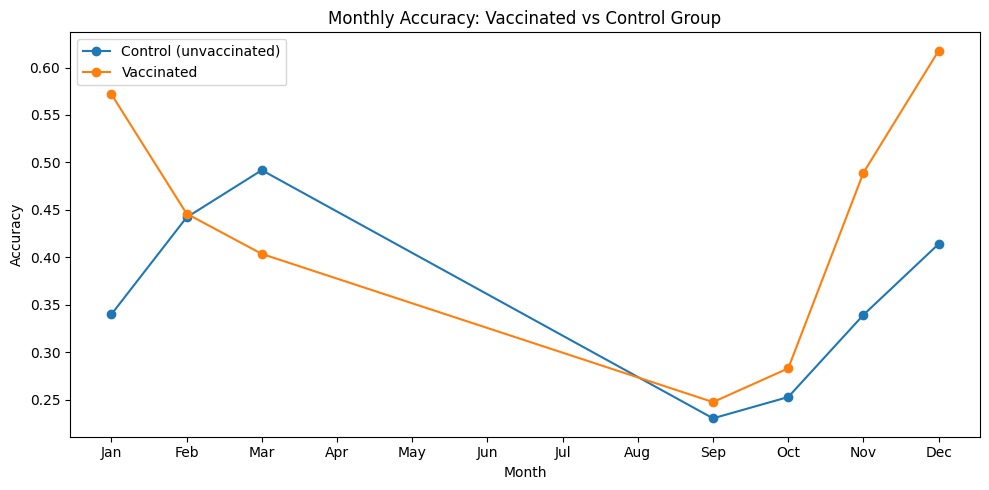

In [82]:
import matplotlib.pyplot as plt
control_monthly = control.groupby(control['test_date'].dt.month)['is_correct'].mean()
vaccinated = df[df['is_vaccinated'] == True].copy()
vaccinated_monthly = vaccinated.groupby(vaccinated['test_date'].dt.month)['is_correct'].mean()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(control_monthly.index, control_monthly.values, marker='o', label='Control (unvaccinated)')
plt.plot(vaccinated_monthly.index, vaccinated_monthly.values, marker='o', label='Vaccinated')

plt.xlabel('Month')
plt.ylabel('Accuracy')
plt.title('Monthly Accuracy: Vaccinated vs Control Group')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.tight_layout()
plt.show()

The groups don't appear to have been equivalent at the start. If vaccinated rats were already higher performers in January, can we cleanly argue the vaccine caused later improvements?

But the vaccines weren't all administered on the same date -> maybe worth plotting accuracy relative to each rat's own vaccination date 

In [83]:
# Calculating days relative to each rat's vaccination date
vaccinated['days_relative'] = (vaccinated['test_date'] - vaccinated['vaccine_date']).dt.days

print(vaccinated['days_relative'].describe())

count    8415.000000
mean       -1.875460
std        31.348273
min       -75.000000
25%       -24.000000
50%        -1.000000
75%        21.000000
max        77.000000
Name: days_relative, dtype: float64


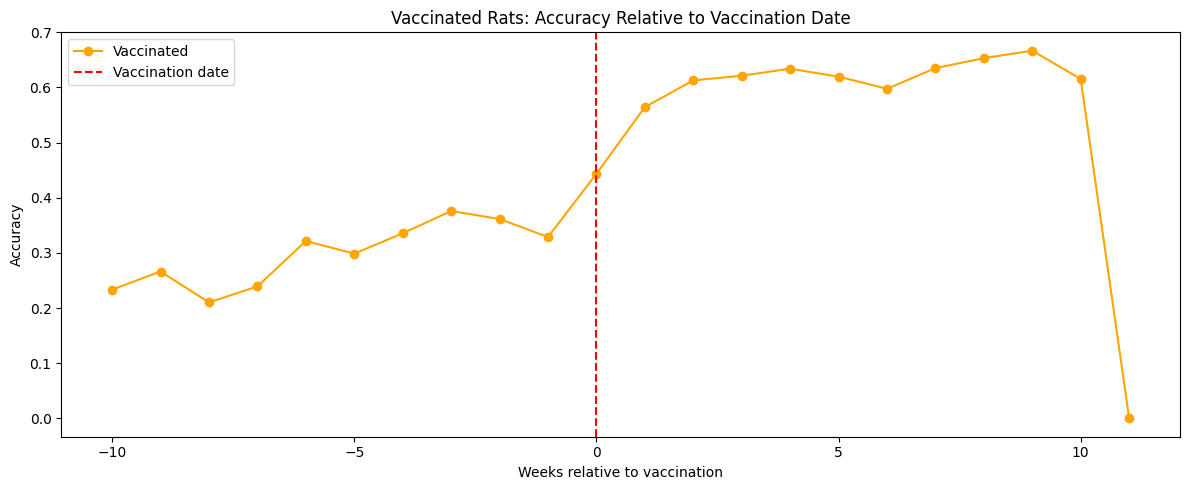

In [84]:
# Bucket by weeks relative to vaccination
vaccinated['week_relative'] = (vaccinated['days_relative'] / 7).apply(lambda x: int(x))

weekly_accuracy = vaccinated.groupby('week_relative')['is_correct'].mean()

plt.figure(figsize=(12, 5))
plt.plot(weekly_accuracy.index, weekly_accuracy.values, marker='o', color='orange', label='Vaccinated')
plt.axvline(x=0, color='red', linestyle='--', label='Vaccination date')
plt.xlabel('Weeks relative to vaccination')
plt.ylabel('Accuracy')
plt.title('Vaccinated Rats: Accuracy Relative to Vaccination Date')
plt.legend()
plt.tight_layout()
plt.show()

Before vaccination -> accuracy is low and noisy, hovering between 21-38% -> No clear upward trend i.e. the rats aren't naturally improving over time

At vaccination (week 0) -> there's an immediate jump from ~33% to ~44% right at the vaccination date

After vaccination -> accuracy climbs steadily and stabilises around 60-65% for several weeks

Drop at week 11: Accuracy crashes to nearly 0% at the very end -> will dig deeper into week 11

In [85]:
# checking if week 11's strange result is due to limited testing occuring 
print(vaccinated.groupby('week_relative')['is_correct'].count())


week_relative
-10      60
-9      169
-8      195
-7      255
-6      339
-5      375
-4      456
-3      524
-2      675
-1      663
 0     1299
 1      629
 2      607
 3      544
 4      481
 5      389
 6      333
 7      211
 8      124
 9       60
 10      26
 11       1
Name: is_correct, dtype: int64


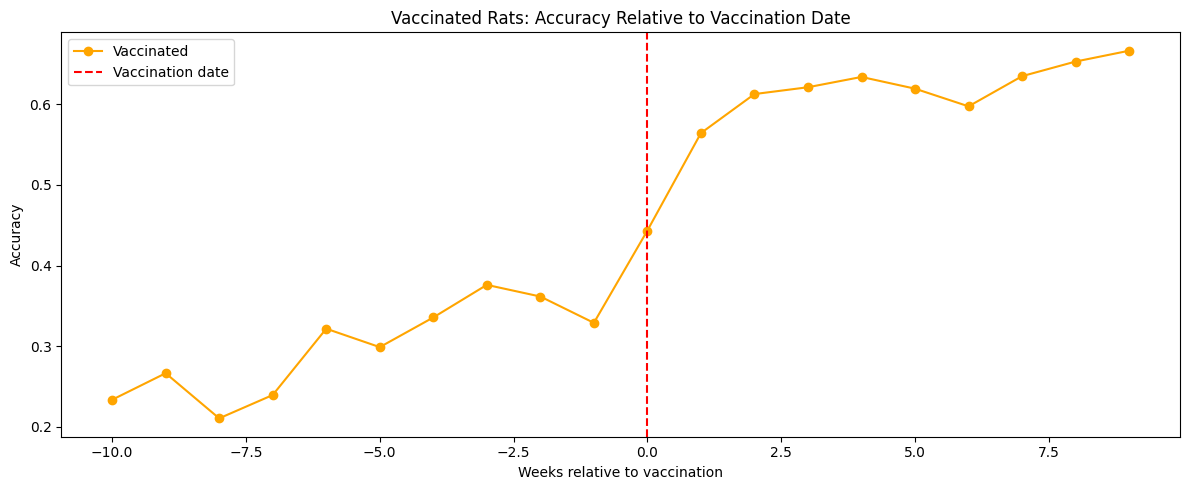

In [86]:
# week 11 only had 1 test -> checking what happens if we filter out weeks with very few tests (threshhold of 30)
min_tests = 30  
reliable_weeks = vaccinated.groupby('week_relative')['is_correct'].count()
reliable_weeks = reliable_weeks[reliable_weeks >= min_tests].index

vaccinated_reliable = vaccinated[vaccinated['week_relative'].isin(reliable_weeks)]
weekly_accuracy = vaccinated_reliable.groupby('week_relative')['is_correct'].mean()

plt.figure(figsize=(12, 5))
plt.plot(weekly_accuracy.index, weekly_accuracy.values, marker='o', color='orange', label='Vaccinated')
plt.axvline(x=0, color='red', linestyle='--', label='Vaccination date')
plt.xlabel('Weeks relative to vaccination')
plt.ylabel('Accuracy')
plt.title('Vaccinated Rats: Accuracy Relative to Vaccination Date')
plt.legend()
plt.tight_layout()
plt.show()

Looks better

Before vaccination -> accuracy is low and relatively flat, ranging between 21–38% -> a very slight upward lift in the last few weeks before vaccination, worth noting?

At vaccination -> big jump to ~44% 

After vaccination -> steady climb from 44% → 66% over 9 weeks

The improvement is sustained and continues growing -> doesn't appear to be a one-off fluke